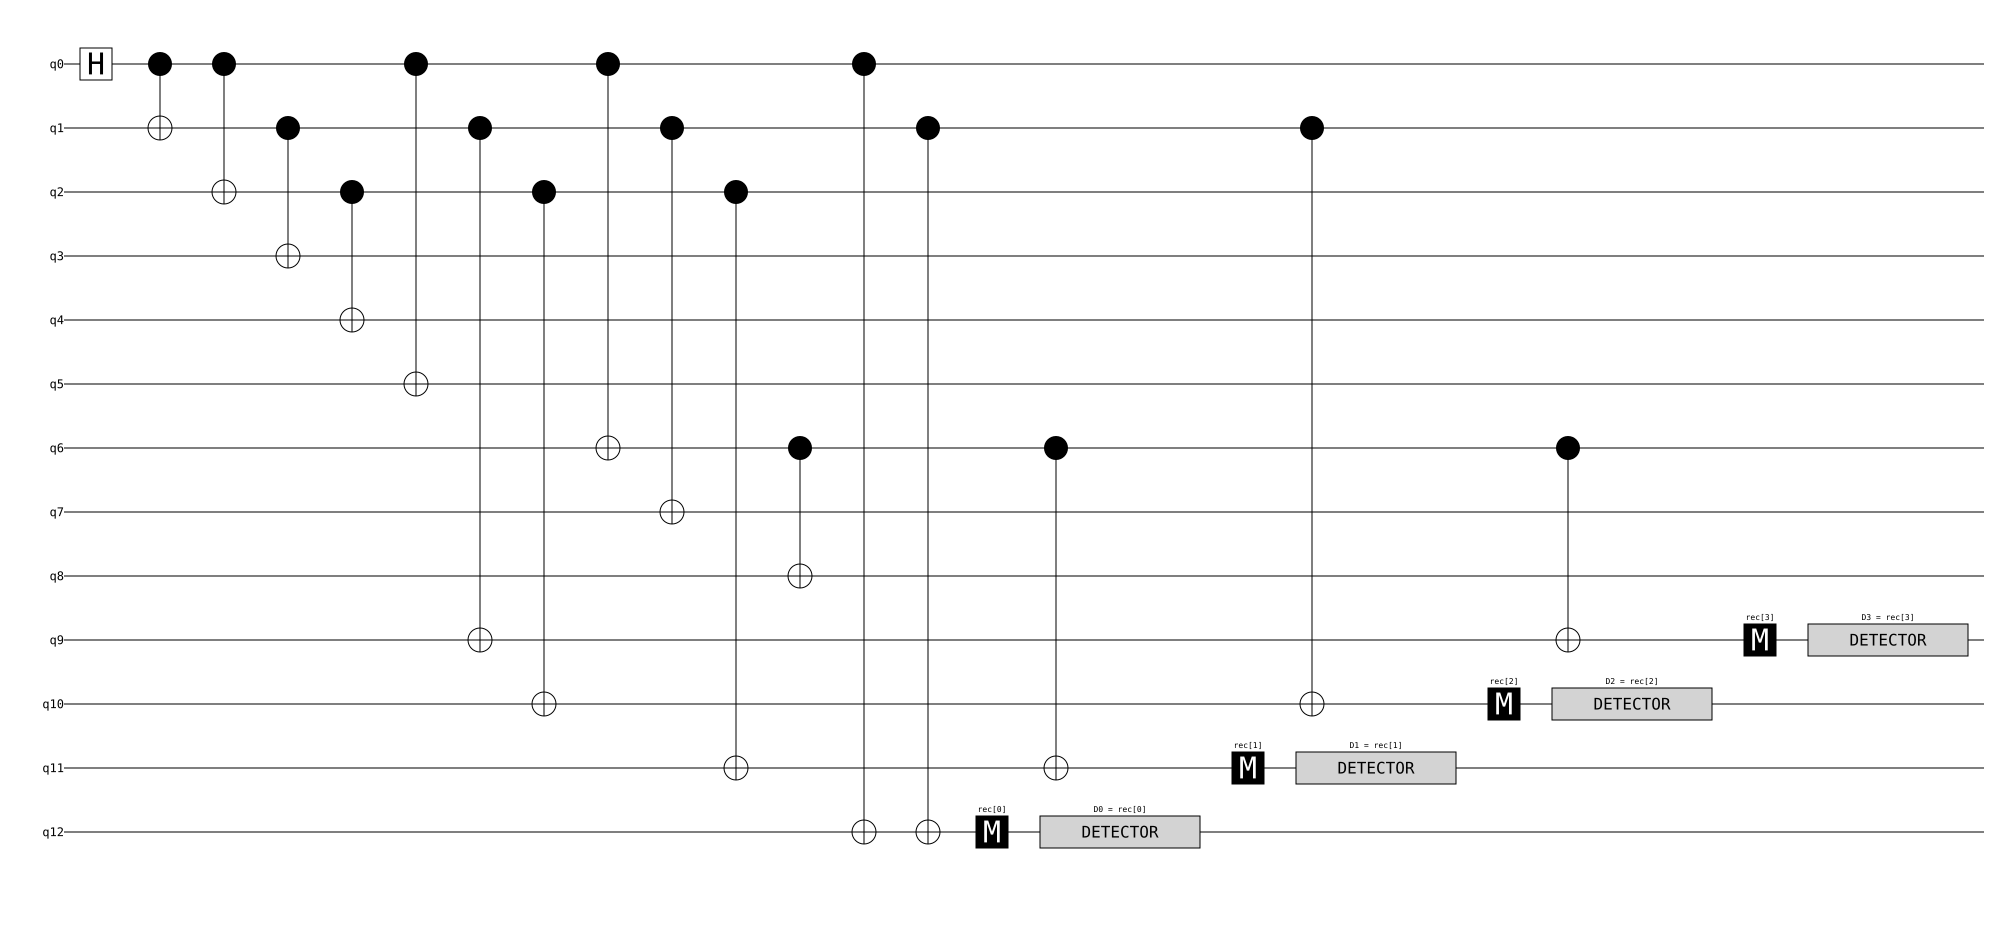

In [1]:
import stim

stim.Circuit("""
H 0
CX 0 1 0 2 1 3 2 4 0 5 1 9 2 10 0 6 1 7 2 11 6 8 0 12 1 12
M 12
DETECTOR rec[-1]
CX 6 11
M 11
DETECTOR rec[-1]
CX 1 10
M 10
DETECTOR rec[-1]
CX 6 9
M 9
DETECTOR rec[-1]
""").diagram('timeline-svg')

In [45]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Pauli
from itertools import product

def build_base_circuit():
    qc = QuantumCircuit(10)
    # Block 1
    qc.h([2, 3, 4, 5])
    qc.cx(2, 7)
    qc.cx(3, 1)
    qc.cx(5, 6)
    qc.cx(2, 0)
    qc.rzz(0.1 * 2 * np.pi, 2, 3)
    qc.cx(2, 7)
    qc.cx(4, 3)
    qc.cx(5, 2)
    qc.cx(4, 6)
    qc.cx(2, 1)
    qc.cx(3, 5)

    # Blocks 2-5
    qc.cx(0, 8); qc.h(9); qc.cx(9, 1)
    qc.cx(1, 8); qc.cx(9, 0)
    qc.cx(4, 8); qc.cx(9, 5)
    qc.cx(5, 8); qc.cx(9, 4); qc.h(9)
    return qc

def build_base_circuit():
    qc = QuantumCircuit(11) # Updated to 11 qubits
    # Block 1
    qc.h([2, 3, 4, 5, 9, 10])
    qc.cx(2, 7)
    qc.cx(3, 1)
    qc.cz(10, 9)
    qc.cx(2, 0)
    qc.rzz(0.125 * 2 * np.pi, 2, 3)
    qc.cx(2, 7)
    qc.cx(4, 3)
    qc.cx(10, 8)

    qc.cx(5, 2)
    qc.cx(5, 6)

    qc.cx(4, 6)
    qc.cx(2, 1)
    qc.cx(3, 5)

    # Blocks 2-5 (Updated with q10 and CZs)
    qc.cx(0, 8); qc.cx(9, 1)
    qc.cx(1, 8); qc.cx(9, 0)
    qc.cx(4, 8); qc.cx(9, 5)
    qc.cz(10, 9)
    qc.cx(10, 8)
    qc.cx(5, 8); qc.cx(9, 4)
    qc.h([9, 10])
    return qc

def generate_target_paulis(target_weight, num_qubits):
    """Generates Pauli strings for the 7 data qubits of a specific weight."""
    paulis = []
    bases = ['I', 'X', 'Y', 'Z']
    for comb in product(bases, repeat=7):
        w = sum(1 for c in comb if c != 'I')
        if w == target_weight:
            # Qiskit orders strings qN...q0. Data is q0-q6.
            q_chars = ['I'] * num_qubits
            labels = []
            for i, c in enumerate(comb):
                if c != 'I':
                    q_chars[(num_qubits - 1) - i] = c
                    labels.append(f"{c}{i}")

            qiskit_str = "".join(q_chars)
            paulis.append((qiskit_str, " ".join(labels)))
    return paulis

def project_and_normalize(sv_data, num_qubits):
    """Projects onto the flags=0 subspace dynamically and normalizes."""
    data = sv_data.copy()

    # Create a dynamic bitmask for all flag qubits (q7 to num_qubits-1)
    flag_mask = sum(1 << i for i in range(7, num_qubits))
    sv_size = 2**num_qubits

    for idx in range(sv_size):
        if (idx & flag_mask) != 0:
            data[idx] = 0.0

    prob = np.sum(np.abs(data)**2)
    if prob > 1e-8:
        data = data / np.sqrt(prob)
    return data, prob

def analyze_fault_tolerance():
    base_qc = build_base_circuit()
    num_qubits = base_qc.num_qubits
    num_instructions = len(base_qc.data)

    # Generate ideal accepted state
    ideal_sv = Statevector(base_qc)
    ideal_acc_data, ideal_prob = project_and_normalize(ideal_sv.data, num_qubits)

    w1_paulis = generate_target_paulis(1, num_qubits)
    w2_paulis = generate_target_paulis(2, num_qubits)

    paulis_1q = ['X', 'Y', 'Z']
    paulis_2q = [''.join(p) for p in product(['I', 'X', 'Y', 'Z'], repeat=2) if ''.join(p) != 'II']

    print(f"Running Absolute Fidelity Verification ({num_qubits} Qubits)...")
    print("Failure Criteria: Faulty state cannot be corrected by ANY weight <= 1 operator.\n")

    failures_count = 0

    for loc in range(num_instructions):
        instr = base_qc.data[loc]
        q_indices = [base_qc.find_bit(q).index for q in instr.qubits]
        errors_to_test = paulis_2q if len(q_indices) == 2 else paulis_1q

        for error_str in errors_to_test:
            test_qc = QuantumCircuit(num_qubits)

            # 1. Run up to fault location
            for i in range(loc + 1):
                test_qc.append(base_qc.data[i].operation, base_qc.data[i].qubits)

            # 2. Inject fault
            for char_idx, q_idx in enumerate(q_indices):
                p_err = error_str[char_idx]
                if p_err == 'X': test_qc.x(q_idx)
                elif p_err == 'Y': test_qc.y(q_idx)
                elif p_err == 'Z': test_qc.z(q_idx)

            # 3. Complete circuit
            for i in range(loc + 1, num_instructions):
                test_qc.append(base_qc.data[i].operation, base_qc.data[i].qubits)

            sv = Statevector(test_qc)
            err_acc_data, err_prob = project_and_normalize(sv.data, num_qubits)

            # If the flags caught it perfectly, move on
            if err_prob < 1e-6:
                continue

            # --- EVALUATE TRUE PHYSICAL DISTANCE ---

            # Check 1: Is it physically equivalent to NO error? (Weight 0)
            f0 = np.abs(np.vdot(err_acc_data, ideal_acc_data))**2
            if f0 > 0.9999:
                continue

            # Check 2: Is it physically equivalent to ANY Weight 1 error?
            is_w1 = False
            for p_str, label in w1_paulis:
                p_ideal_sv = Statevector(ideal_acc_data).evolve(Pauli(p_str))
                f1 = np.abs(np.vdot(err_acc_data, p_ideal_sv.data))**2
                if f1 > 0.9999:
                    is_w1 = True
                    break

            if is_w1:
                continue

            # Definitively a code-breaking failure
            failures_count += 1
            matched_w2 = False

            for p_str, label in w2_paulis:
                p_ideal_sv = Statevector(ideal_acc_data).evolve(Pauli(p_str))
                f2 = np.abs(np.vdot(err_acc_data, p_ideal_sv.data))**2
                if f2 > 0.9999:
                    print(f"❌ TRUE FAULT-TOLERANCE FAILURE")
                    print(f"  - Injection: Gate {loc} ({instr.operation.name}) on {q_indices}")
                    print(f"  - Fault Type: {error_str}")
                    print(f"  - Escaped Data Error: {label} (Exact Weight 2 Match)")
                    print(f"  - Acceptance Prob: {err_prob:.4f}")
                    print("-" * 60)
                    matched_w2 = True
                    break

            if not matched_w2:
                print(f"❌ TRUE FAULT-TOLERANCE FAILURE")
                print(f"  - Injection: Gate {loc} ({instr.operation.name}) on {q_indices}")
                print(f"  - Fault Type: {error_str}")
                print(f"  - Escaped Data Error: Coherent/Complex State (Uncorrectable by d=3)")
                print(f"  - Acceptance Prob: {err_prob:.4f}")
                print("-" * 60)

    if failures_count == 0:
        print("✅ Success! All accepted physical states are correctable via distance-3 recovery.")
    else:
        print(f"Analysis complete. Found {failures_count} true uncorrectable physical violations.")

if __name__ == "__main__":
    analyze_fault_tolerance()

Running Absolute Fidelity Verification (11 Qubits)...
Failure Criteria: Faulty state cannot be corrected by ANY weight <= 1 operator.

❌ TRUE FAULT-TOLERANCE FAILURE
  - Injection: Gate 10 (rzz) on [2, 3]
  - Fault Type: ZZ
  - Escaped Data Error: Coherent/Complex State (Uncorrectable by d=3)
  - Acceptance Prob: 1.0000
------------------------------------------------------------
Analysis complete. Found 1 true uncorrectable physical violations.


In [46]:
# Disables folding completely
build_base_circuit().draw(fold=-1)

┌───┐                                                       ┌───┐                            
 q_0: ───────────────┤ X ├────────────■──────────────────────────────────────────┤ X ├────────────────────────────
                ┌───┐└─┬─┘            │                 ┌───┐          ┌───┐     └─┬─┘                            
 q_1: ──────────┤ X ├──┼──────────────┼─────────────────┤ X ├──────────┤ X ├──■────┼──────────────────────────────
      ┌───┐     └─┬─┘  │              │            ┌───┐└─┬─┘          └─┬─┘  │    │                              
 q_2: ┤ H ├──■────┼────■───■──────────┼────■───────┤ X ├──■──────────────┼────┼────┼──────────────────────────────
      ├───┤  │    │        │ZZ(π/4)   │    │  ┌───┐└─┬─┘                 │    │    │                              
 q_3: ┤ H ├──┼────■────────■──────────┼────┼──┤ X ├──┼──────────────■────┼────┼────┼──────────────────────────────
      ├───┤  │                        │    │  └─┬─┘  │              │    │    │    │                    ┌───┐     
 q_4: ┤ H ├──┼────────────────────────┼────┼────■────┼─────────■────┼────┼────┼────┼────■───────────────┤ X ├─────
      ├───┤  │                        │    │         │         │  ┌─┴─┐  │    │    │    │  ┌───┐        └─┬─┘     
 q_5: ┤ H ├──┼────────────────────────┼────┼─────────■────■────┼──┤ X ├──┼────┼────┼────┼──┤ X ├──────────┼────■──
      └───┘  │                        │    │            ┌─┴─┐┌─┴─┐└───┘  │    │    │    │  └─┬─┘          │    │  
 q_6: ───────┼────────────────────────┼────┼────────────┤ X ├┤ X ├───────┼────┼────┼────┼────┼────────────┼────┼──
           ┌─┴─┐                      │  ┌─┴─┐          └───┘└───┘       │    │    │    │    │            │    │  
 q_7: ─────┤ X ├──────────────────────┼──┤ X ├───────────────────────────┼────┼────┼────┼────┼────────────┼────┼──
           └───┘┌───┐               ┌─┴─┐└───┘                           │  ┌─┴─┐  │  ┌─┴─┐  │     ┌───┐  │  ┌─┴─┐
 q_8: ──────────┤ X ├───────────────┤ X ├────────────────────────────────┼──┤ X ├──┼──┤ X ├──┼─────┤ X ├──┼──┤ X ├
      ┌───┐     └─┬─┘               └───┘                                │  └───┘  │  └───┘  │     └─┬─┘  │  ├───┤
 q_9: ┤ H ├──■────┼──────────────────────────────────────────────────────■─────────■─────────■───■───┼────■──┤ H ├
      ├───┤  │    │                                                                              │   │  ┌───┐└───┘
q_10: ┤ H ├──■────■──────────────────────────────────────────────────────────────────────────────■───■──┤ H ├─────
      └───┘                                                                                             └───┘

In [66]:
from spiderstate.utils import load_qecc

is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc("8_3_2", "MQT")
ixs = np.where(H_x)[1]
for r in H_x:
    ixs = np.where(r)[0]
    print(" ".join([f"X_{{{i + 1}}}" for i in ixs]))
ixs = np.where(H_z)[1]
for r in H_z:
    ixs = np.where(r)[0]
    print(" ".join([f"Z_{{{i + 1}}}" for i in ixs]))


X_{1} X_{2} X_{3} X_{4} X_{5} X_{6} X_{7} X_{8}
Z_{1} Z_{2} Z_{3} Z_{4} Z_{5} Z_{6} Z_{7} Z_{8}
Z_{1} Z_{2} Z_{3} Z_{4}
Z_{1} Z_{2} Z_{5} Z_{6}
Z_{1} Z_{3} Z_{5} Z_{7}


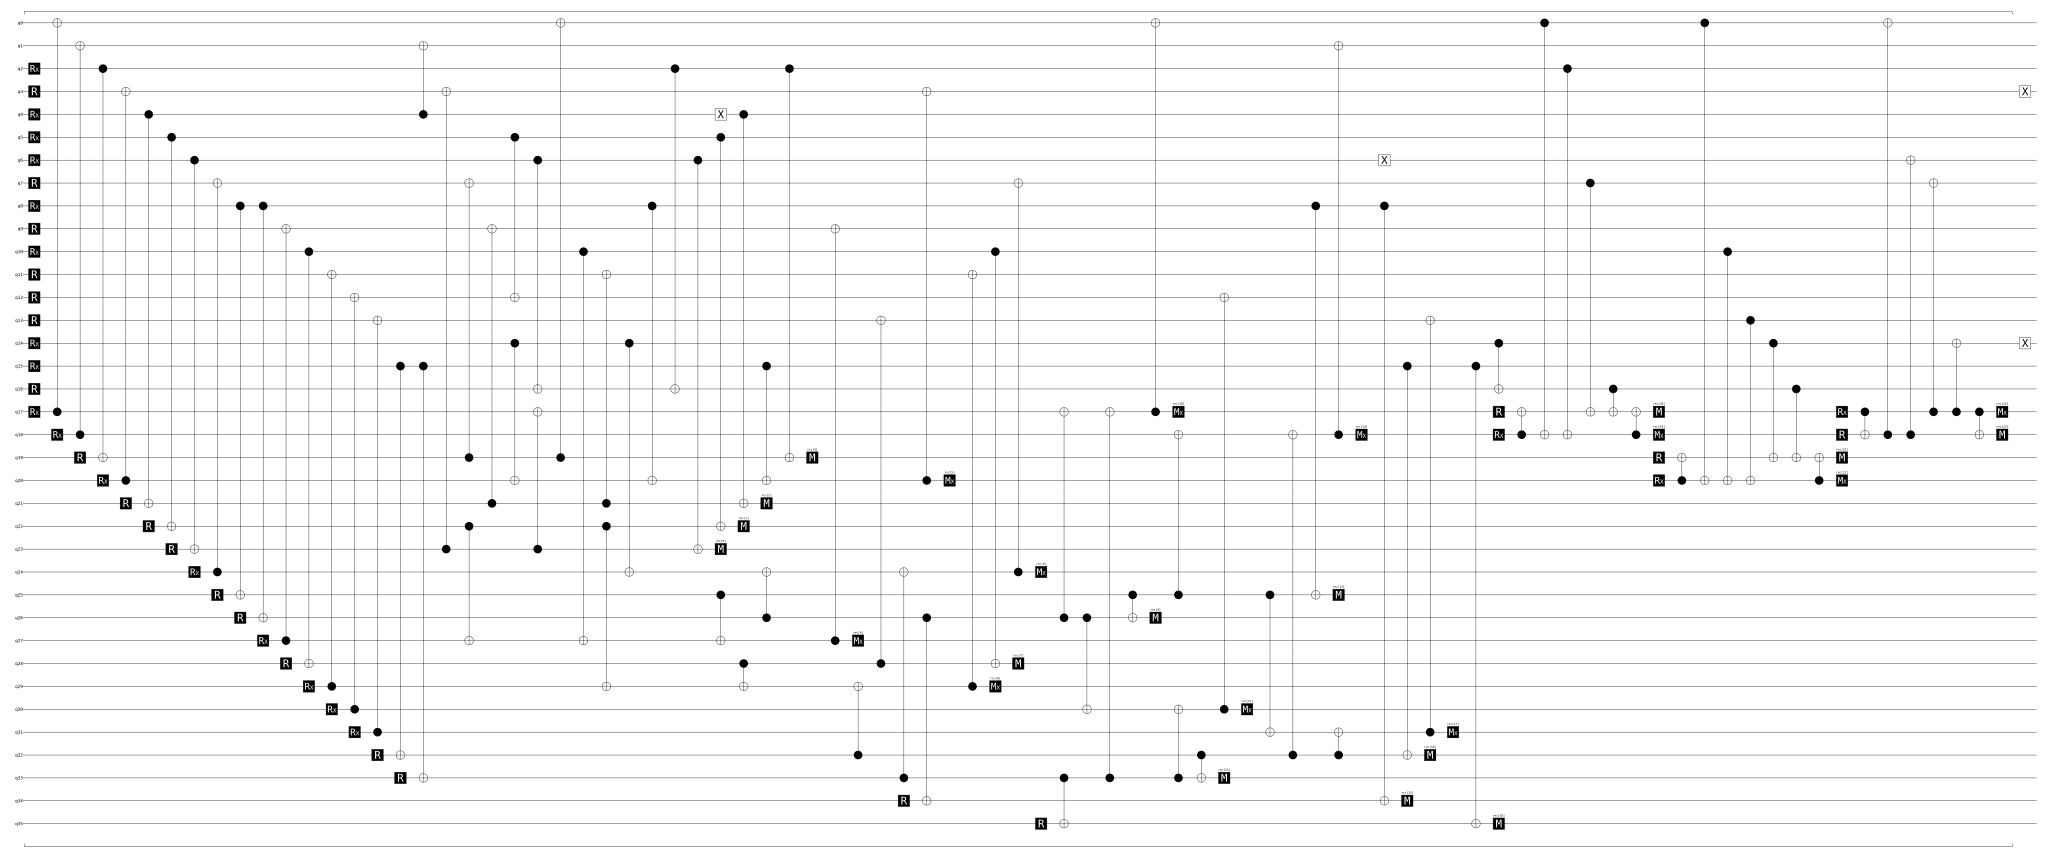

In [1]:
import stim

stim.Circuit("""
RX 2
R 3
RX 4 5 6
R 7
RX 8
R 9
RX 10
R 11 12 13
RX 14 15
R 16
RX 17
CX 17 0
RX 18
CX 18 1
R 19
CX 2 19
RX 20
CX 20 3
R 21
CX 4 21
R 22
CX 5 22
R 23
CX 6 23
RX 24
CX 24 7
R 25
CX 8 25
R 26
CX 8 26
RX 27
CX 27 9
R 28
CX 10 28
RX 29
CX 29 11
RX 30
CX 30 12
RX 31
CX 31 13
R 32
CX 15 32
R 33
CX 15 33 4 1 23 3 19 7 22 27 21 9 5 12 14 20 6 16 23 17 19 0 10 27 22 29 21 11 14 24 8 20 2 16 6 23
M 23
X 4
CX 25 27 5 22
M 22
CX 28 29 4 21
M 21
CX 26 24 15 20 2 19
M 19
CX 27 9
MX 27
CX 32 29 28 13 33 24
R 34
CX 26 34 20 3
MX 20
CX 29 11
MX 29
CX 10 28
M 28
CX 24 7
MX 24
R 35
CX 33 35 26 17 26 30 33 17 25 26
M 26
CX 17 0
MX 17
CX 33 30 25 18 32 33
M 33
CX 30 12
MX 30
CX 25 31 32 18 8 25
M 25
CX 32 31 18 1
MX 18
CX 8 34
X 6
M 34
CX 15 32
M 32
CX 31 13
MX 31
CX 15 35
M 35
CX 14 16
R 17
RX 18
CX 18 17 0 18 2 18 7 17 16 17 18 17
MX 18
M 17
R 19
RX 20
CX 20 19 0 20 10 20 13 20 14 19 16 19 20 19
MX 20
M 19
RX 17
R 18
CX 17 18 18 0 18 6 17 7 17 14 17 18
M 18
MX 17
TICK
X 3 14
""").diagram('timeline-svg')

In [ ]:
"